# About

# Section 1 : Install and import Libraries

In [2]:
import pandas as pd
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

In [3]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Section 2: Extracting Stock Market Data

Extract the data from yahoo finance API

In [4]:
tesla = yf.Ticker('TSLA')
share_tesla = tesla.history(period='max').reset_index()
share_tesla

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0
...,...,...,...,...,...,...,...,...
3987,2026-05-06 00:00:00-04:00,386.250000,401.679993,384.019989,398.730011,53465400,0.0,0.0
3988,2026-05-07 00:00:00-04:00,407.480011,415.829987,402.119995,411.790009,64294200,0.0,0.0
3989,2026-05-08 00:00:00-04:00,416.480011,431.200012,416.390015,428.350006,65050000,0.0,0.0
3990,2026-05-11 00:00:00-04:00,422.160004,449.160004,416.799988,445.000000,78376100,0.0,0.0


In [5]:
gamestop = yf.Ticker('GME')
share_gamestop = gamestop.history(period='max').reset_index()
share_gamestop

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716073,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578048,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662209,1.603296,1.662209,6892800,0.0,0.0
...,...,...,...,...,...,...,...,...
6095,2026-05-06 00:00:00-04:00,24.299999,25.440001,23.959999,25.170000,11606500,0.0,0.0
6096,2026-05-07 00:00:00-04:00,25.120001,25.250000,23.790001,23.969999,8794000,0.0,0.0
6097,2026-05-08 00:00:00-04:00,24.139999,24.420000,23.820000,24.280001,5957700,0.0,0.0
6098,2026-05-11 00:00:00-04:00,24.200001,24.370001,23.100000,23.170000,17915500,0.0,0.0


# Section 3: Additional Income/Profit Data

### Revenue Data Extraction

For this project, the historical revenue data was extracted from Macrotrends.  
This website provides financial tables with company fundamentals, including revenue data for Tesla and GameStop.  

The purpose of using this source is to compare each company’s stock price performance with its reported revenue over time.

#### Tesla Revenue

In [6]:
url_tesla = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue?"
data_tsla = requests.get(url_tesla).text

In [7]:
#Parsing the data using Beautiful soup library
soup_tsla = BeautifulSoup(data_tsla, 'html.parser')


### Note on Revenue Data Source

Macrotrends was initially considered as a source for historical revenue data. However, direct requests to the website returned a Cloudflare protection page instead of the actual financial table, which prevented automated extraction.

To continue the analysis and web scraping practice, an alternative public source with accessible revenue history tables was used.

In [8]:
url_tesla = "https://companiesmarketcap.com/tesla/revenue/"
html_tesla = requests.get(url_tesla).text
html_tesla

'<!DOCTYPE html>\n<html lang="en-US">\n<head>\n<title>Tesla (TSLA) - Revenue</title>\n<meta charset="utf-8"/>\n<link rel="shortcut icon" href="https://companiesmarketcap.com/favicon.ico" type="image/x-icon">\n<link rel="apple-touch-icon" sizes="57x57" href="/img/icons/apple-icon-57x57.png">\n<link rel="apple-touch-icon" sizes="60x60" href="/img/icons/apple-icon-60x60.png">\n<link rel="apple-touch-icon" sizes="72x72" href="/img/icons/apple-icon-72x72.png">\n<link rel="apple-touch-icon" sizes="76x76" href="/img/icons/apple-icon-76x76.png">\n<link rel="apple-touch-icon" sizes="114x114" href="/img/icons/apple-icon-114x114.png">\n<link rel="apple-touch-icon" sizes="120x120" href="/img/icons/apple-icon-120x120.png">\n<link rel="apple-touch-icon" sizes="144x144" href="/img/icons/apple-icon-144x144.png">\n<link rel="apple-touch-icon" sizes="152x152" href="/img/icons/apple-icon-152x152.png">\n<link rel="apple-touch-icon" sizes="180x180" href="/img/icons/apple-icon-180x180.png">\n<link rel="icon

In [9]:
#Parsing the data with beautiful soup
parse_revenue_tesla = BeautifulSoup(html_tesla, "html.parser")

In [10]:
table_revenue_tesla = parse_revenue_tesla.find("table")
rows = table_revenue_tesla.find("tbody").find_all("tr")

final_data_tesla = []

for row in rows:
    columns = row.find_all("td")
    year = columns[0].text
    revenue = columns[1].text
    
    final_data_tesla.append({'Year': year,
                       'Revenue': revenue})

revenue_tesla = pd.DataFrame(final_data_tesla) 
revenue_tesla


,Year,Revenue
0,2026 (TTM),$97.87 B
1,2025,$94.82 B
2,2024,$97.69 B
3,2023,$96.77 B
4,2022,$81.46 B
5,2021,$53.82 B
6,2020,$31.53 B
7,2019,$24.57 B
8,2018,$21.46 B
9,2017,$11.75 B


#### Gamestop Revenue

In [11]:
url_gamestop = 'https://companiesmarketcap.com/gamestop/revenue/'
html_gme = requests.get(url_gamestop).text

In [12]:
#Parsing with beautiful soup
parse_revenue_gme = BeautifulSoup(html_gme, "html.parser")

In [13]:
table_revenue_gme = parse_revenue_gme.find("table")
rows_gme = table_revenue_gme.find("tbody").find_all("tr")

final_data_gme = []

for row in rows_gme:
    cols = row.find_all("td")
    year = cols[0].text
    revenue = cols[1].text

    final_data_gme.append({'Year': year,
                           'Revenue': revenue})
    
revenue_gme = pd.DataFrame(final_data_gme)
revenue_gme



,Year,Revenue
0,2026 (TTM),$3.62 B
1,2025,$3.62 B
2,2024,$3.82 B
3,2023,$5.27 B
4,2022,$5.92 B
5,2021,$6.01 B
6,2020,$5.08 B
7,2019,$6.46 B
8,2018,$7.84 B
9,2017,$9.22 B


# Section 4: Cleaning Data

#### Cleaning Tesla Revenue DataFrame

In [16]:
revenue_tesla.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Year     18 non-null     str  
 1   Revenue  18 non-null     str  
dtypes: str(2)
memory usage: 420.0 bytes


In [22]:
revenue_tesla_clean = revenue_tesla.copy()

In [26]:
revenue_tesla_clean["Year"] = revenue_tesla_clean["Year"].str.strip()
revenue_tesla_clean['Revenue'] = revenue_tesla_clean['Revenue'].str.strip()

In [25]:
revenue_tesla_clean = revenue_tesla_clean[~revenue_tesla_clean['Year'].str.contains('TTM', na=False)]

In [28]:
revenue_tesla_clean['Year'] = pd.to_numeric(revenue_tesla_clean['Year'], errors='raise')

In [29]:
revenue_tesla_clean['Revenue'] = revenue_tesla_clean['Revenue'].str.replace('$', '', regex=False)
revenue_tesla_clean['Revenue'] = revenue_tesla_clean['Revenue'].str.replace('B', '', regex=False)

In [32]:
revenue_tesla_clean['Revenue'] = pd.to_numeric(revenue_tesla_clean['Revenue'], errors='raise')

In [36]:
revenue_tesla_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 1 to 17
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     17 non-null     int64  
 1   Revenue  17 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 404.0 bytes


In [53]:
revenue_tesla_clean = revenue_tesla_clean.rename(columns= {'Revenue': 'Revenue (Billion USD)'})

In [54]:
revenue_tesla_clean

,Year,Revenue (Billion USD)
1,2025,94.82
2,2024,97.69
3,2023,96.77
4,2022,81.46
5,2021,53.82
6,2020,31.53
7,2019,24.57
8,2018,21.46
9,2017,11.75
10,2016,7.00


#### Cleaning GamesTop Revenue DataFrame

In [43]:
revenue_gme.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Year     26 non-null     str  
 1   Revenue  26 non-null     str  
dtypes: str(2)
memory usage: 548.0 bytes


In [39]:
revenue_gme_clean = revenue_gme.copy()

In [40]:
#remove any space at the beginning or end
revenue_gme_clean['Year'] = revenue_gme_clean['Year'].str.strip()
revenue_gme_clean['Revenue'] = revenue_gme_clean['Revenue'].str.strip()

In [41]:
revenue_gme_clean = revenue_gme_clean[~revenue_gme_clean['Year'].str.contains('TTM', na=False)]

In [44]:
revenue_gme_clean['Year'] = pd.to_numeric(revenue_gme_clean['Year'], errors='raise')

In [45]:
revenue_gme_clean['Revenue'] = revenue_gme_clean['Revenue'].str.replace('$', '', regex=False)
revenue_gme_clean['Revenue'] = revenue_gme_clean['Revenue'].str.replace('B', '', regex=False)

In [46]:
revenue_gme_clean['Revenue'] = pd.to_numeric(revenue_gme_clean['Revenue'], errors='raise')

In [48]:
revenue_gme_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 1 to 25
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     25 non-null     int64  
 1   Revenue  25 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [55]:
revenue_gme_clean = revenue_gme_clean.rename(columns= {'Revenue': 'Revenue (Billion USD)'})

In [56]:
revenue_gme_clean

,Year,Revenue (Billion USD)
1,2025,3.62
2,2024,3.82
3,2023,5.27
4,2022,5.92
5,2021,6.01
6,2020,5.08
7,2019,6.46
8,2018,7.84
9,2017,9.22
10,2016,8.60


# Section 5: Visualization

##### Tesla Stock Price

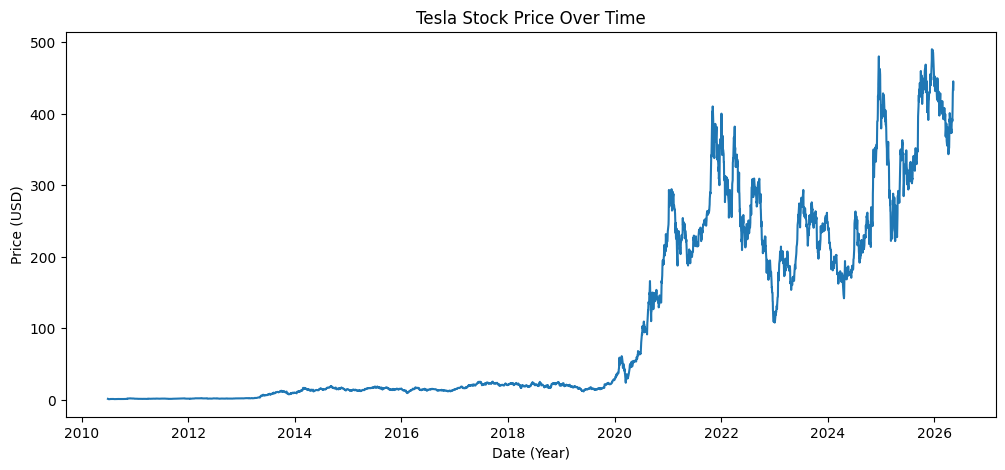

In [63]:
plt.figure(figsize=(12,5))
plt.plot(share_tesla['Date'], share_tesla['Close'])
plt.title('Tesla Stock Price Over Time')
plt.ylabel('Price (USD)')
plt.xlabel('Date (Year)')
plt.show()

##### Tesla Revenue

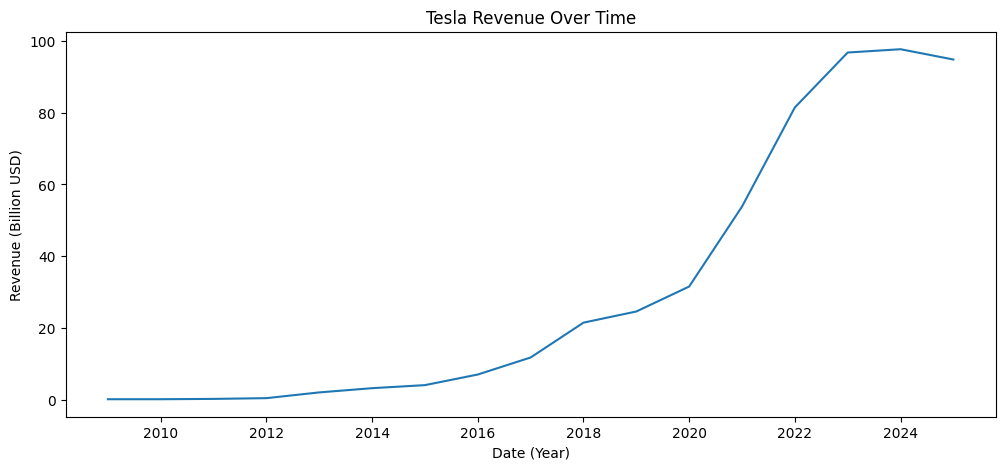

In [67]:
plt.figure(figsize=(12,5))
plt.plot(revenue_tesla_clean['Year'], revenue_tesla_clean['Revenue (Billion USD)'])
plt.title('Tesla Revenue Over Time')
plt.ylabel('Revenue (Billion USD)')
plt.xlabel('Date (Year)')
plt.show()

##### Gamestop Stock Price

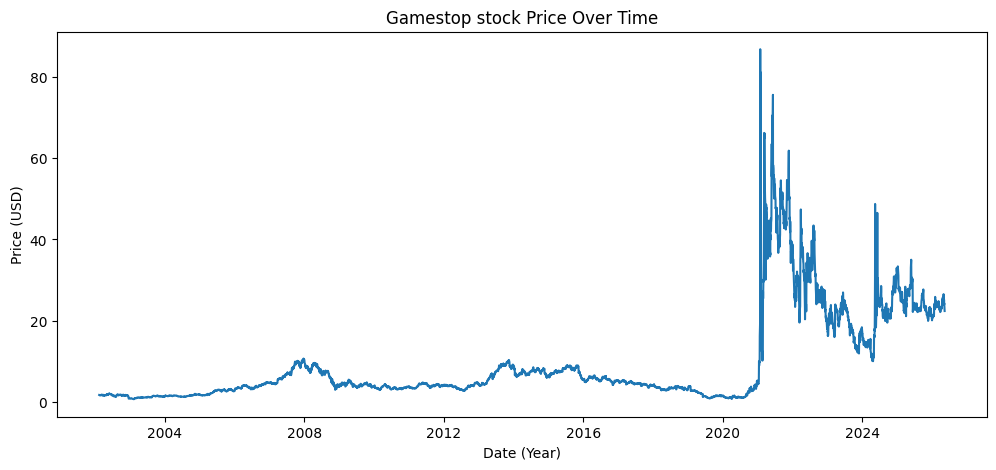

In [68]:
plt.figure(figsize=(12,5))
plt.plot(share_gamestop['Date'], share_gamestop['Close'])
plt.title('Gamestop stock Price Over Time')
plt.ylabel('Price (USD)')
plt.xlabel('Date (Year)')
plt.show()

##### Gamestop Revenue

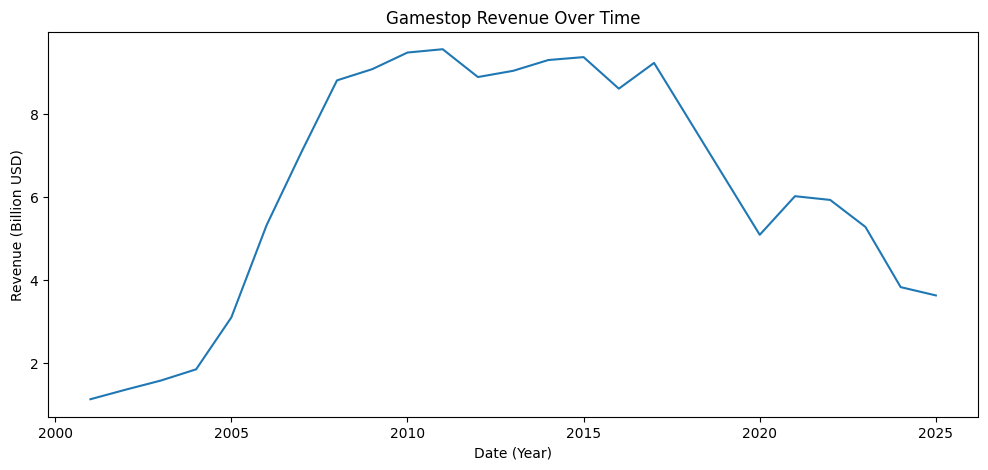

In [69]:
plt.figure(figsize=(12,5))
plt.plot(revenue_gme_clean['Year'], revenue_gme_clean['Revenue (Billion USD)'])
plt.title('Gamestop Revenue Over Time')
plt.ylabel('Revenue (Billion USD)')
plt.xlabel('Date (Year)')
plt.show()

##### Price vs Revenue Comparison

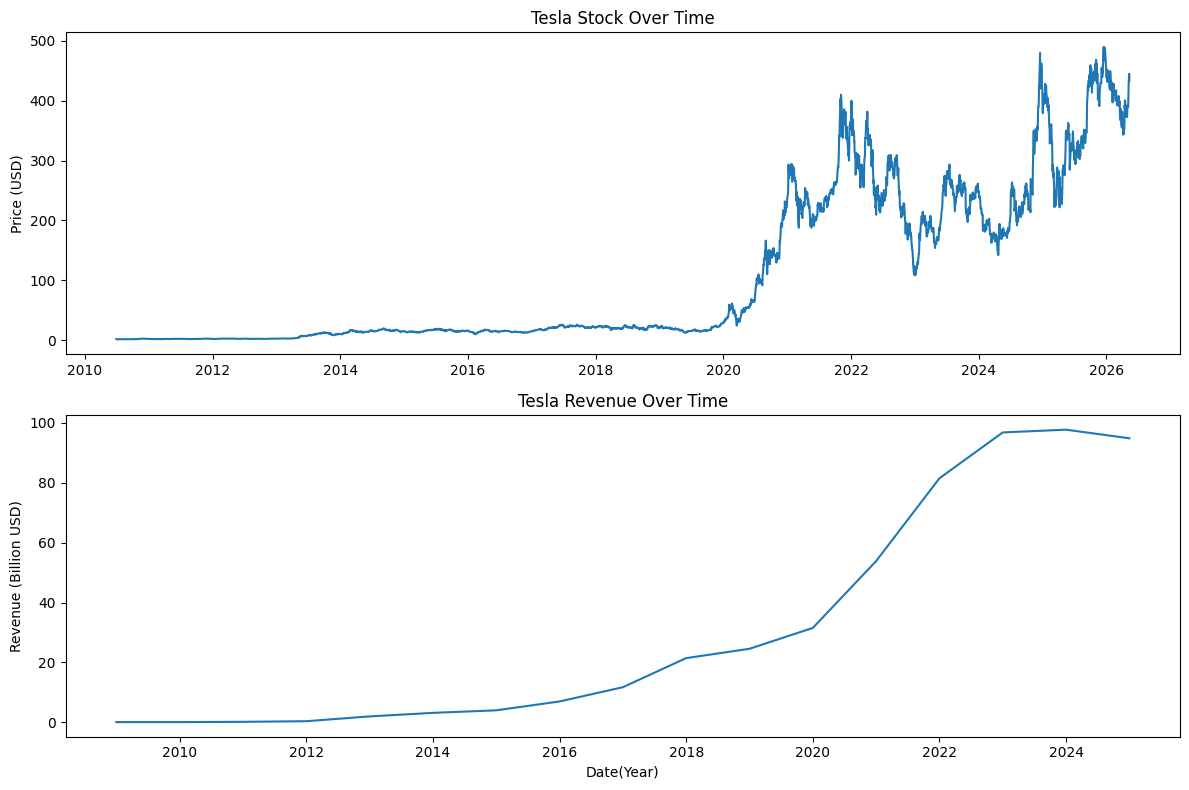

In [72]:
fig, ax = plt.subplots(2, 1, figsize=(12,8))
ax[0].plot(share_tesla['Date'], share_tesla['Close'])
ax[0].set_title('Tesla Stock Over Time')
ax[0].set_ylabel('Price (USD)')

ax[1].plot(revenue_tesla_clean['Year'], revenue_tesla_clean['Revenue (Billion USD)'])
ax[1].set_title('Tesla Revenue Over Time')
ax[1].set_ylabel('Revenue (Billion USD)')
ax[1].set_xlabel('Date(Year)')

plt.tight_layout()
plt.show()

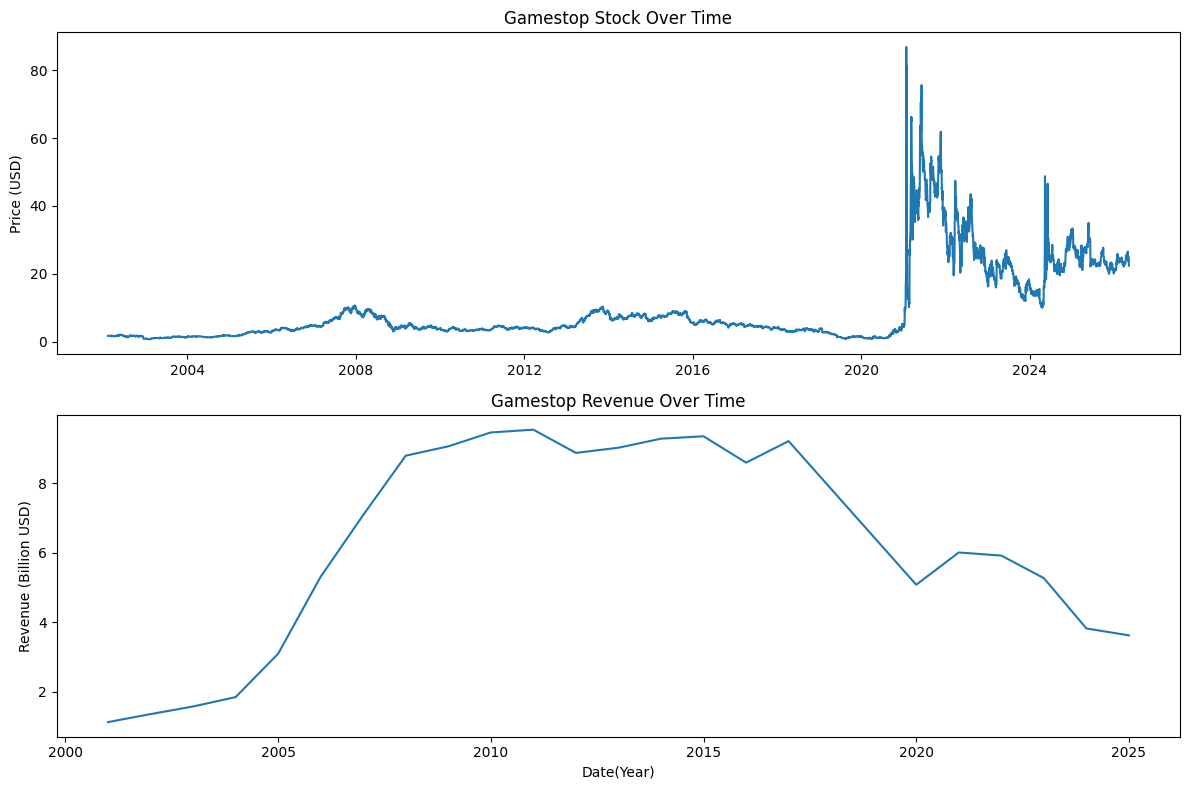

In [73]:
fig, ax = plt.subplots(2, 1, figsize=(12,8))
ax[0].plot(share_gamestop['Date'], share_gamestop['Close'])
ax[0].set_title('Gamestop Stock Over Time')
ax[0].set_ylabel('Price (USD)')

ax[1].plot(revenue_gme_clean['Year'], revenue_gme_clean['Revenue (Billion USD)'])
ax[1].set_title('Gamestop Revenue Over Time')
ax[1].set_ylabel('Revenue (Billion USD)')
ax[1].set_xlabel('Date(Year)')

plt.tight_layout()
plt.show()

# Section 6: Conclusions